### Hybrid CNN-LSTM Model

In [1]:
# Importing Libaries for our model (Hybrid CNN-LSTM model)
import numpy as np
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as plt
import ocf_blosc2
import cv2
import keras_tuner as kt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, TimeDistributed, Conv2DTranspose, Reshape, UpSampling2D
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam


C:\Users\taimo\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


### Model 1 (Default parameteres)

C:\Users\taimo\anaconda3\Lib\site-packages\xarray\core\indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 15 times more chunks
  return self.array[key]
C:\Users\taimo\anaconda3\Lib\site-packages\xarray\core\indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 16 times more chunks
  return self.array[key]


X_train shape: (21, 80, 80)
X_test shape: (9, 80, 80)
y_train shape: (21, 80, 80)
y_test shape: (9, 80, 80)


X_train shape: (1, 21, 80, 80)
X_test shape: (1, 9, 80, 80)
y_train shape: (1, 21, 80, 80)
y_test shape: (1, 9, 80, 80)


X_train shape: (1, 21, 80, 80, 1)
X_test shape: (1, 9, 80, 80, 1)
y_train shape: (1, 21, 80, 80, 1)
y_test shape: (1, 9, 80, 80, 1)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 33s 33s/step - loss: 0.0904 - val_loss: 0.0897
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step - loss: 0.0891 - val_loss: 0.0849
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step - loss: 0.0825 - val_loss: 0.0625
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step - loss: 0.0473 - val_loss: 0.0432
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step - loss: 0.0678 - val_loss: 0.0375
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step - loss: 0.0570 - val_loss: 0.0298
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step - loss: 0.0451 - val_loss: 0.0323
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/st

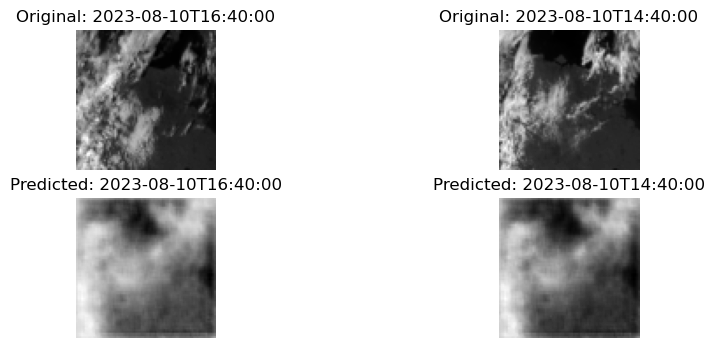

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0217


Test Loss: 0.021720102056860924




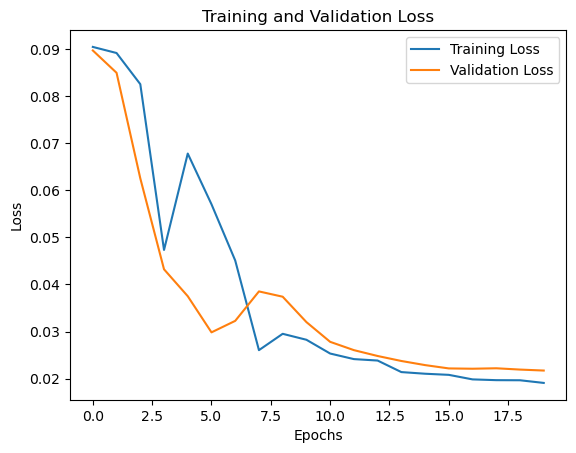

In [2]:
# Loading the dataset
SATELLITE_ZARR_PATH = "gs://public-datasets-eumetsat-solar-forecasting/satellite/EUMETSAT/SEVIRI_RSS/v4/2023_hrv.zarr"
dataset = xr.open_dataset(SATELLITE_ZARR_PATH, engine="zarr", chunks="auto")

# Sorted by time
dataset = dataset.sortby('time')

# Defining the time points
# 5 hrs 12:00 to 17:00 (10th august 2023)
times = ["2023-08-10T12:00:00", "2023-08-10T12:10:00", "2023-08-10T12:20:00", "2023-08-10T12:30:00", "2023-08-10T12:40:00",
    "2023-08-10T12:50:00", "2023-08-10T13:00:00", "2023-08-10T13:10:00", "2023-08-10T13:20:00", "2023-08-10T13:30:00",
    "2023-08-10T13:40:00", "2023-08-10T13:50:00", "2023-08-10T14:00:00", "2023-08-10T14:10:00", "2023-08-10T14:20:00",
    "2023-08-10T14:30:00", "2023-08-10T14:40:00", "2023-08-10T14:50:00", "2023-08-10T15:00:00", "2023-08-10T15:10:00",
    "2023-08-10T15:20:00", "2023-08-10T15:30:00", "2023-08-10T15:40:00", "2023-08-10T15:50:00", "2023-08-10T16:00:00",
    "2023-08-10T16:10:00", "2023-08-10T16:20:00", "2023-08-10T16:30:00", "2023-08-10T16:40:00", "2023-08-10T16:50:00",
    "2023-08-10T17:00:00"]

# Nearest method to ensure all time points are loaded
data = [dataset.sel(time=time, method='nearest') for time in times]

# Coordinates for south of England
x_start, x_end = 1850, 2200  # x-coordinates
y_start, y_end = 3150, 3300  # y-coordinates

# Preprocessing the image
# Downscalling to 80x80 resolution
# Normalization

def preprocess_data(data, downscale_size=(80, 80)):
    data_subsets = [d.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))['data'].squeeze('variable', drop=True) for d in data]
    norm_data = [(d - d.min()) / (d.max() - d.min()) for d in data_subsets]
    images = [(d * 255).astype(np.uint8).values for d in norm_data]
    # Downscale images
    downscaled_images = [resize(image, downscale_size, anti_aliasing=True) for image in images]
    return downscaled_images

images = preprocess_data(data, downscale_size=(80, 80))
images = np.stack(images)

# Creating a sequences of images for time series
# Goal is to predict next image, any image in 'x' is used to predict next image in 'y'
X = images[:-1]
y = images[1:]

# Maintaining a list of corresponding timestamps 
timestamps = times[1:]  # y is the next predicting image

# Spliting data using train-test split
X_train, X_test, y_train, y_test, train_timestamps, test_timestamps = train_test_split(X, y, timestamps, test_size=0.3, random_state=42)

# Printing the shapes of the datasets
# Initialy a 3D array
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print('\n')

# Expand dimensions for time series data 
# Expansion to a 4D array
# Batch size added
X_train = np.expand_dims(X_train, axis=0)
X_test = np.expand_dims(X_test, axis=0)
y_train = np.expand_dims(y_train, axis=0)
y_test = np.expand_dims(y_test, axis=0)

# Printing the shapes of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print('\n')

# Expansion to a 5D array 
# (batch size, Sequence length/time steps, height, width, channels)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
y_train = np.expand_dims(y_train, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

# Printing the shapes of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print('\n')

# Defining the model
# Creating an input layer (shape & type of input)
# 'None' is leaving time steps to be changeable. To be used in a sequence
input_layer = Input(shape=(None, 80, 80, 1))

# CNN for feature extraction
# Flattening features to be used by LSTM
cnn_features = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(input_layer)
cnn_features = TimeDistributed(MaxPooling2D((2, 2)))(cnn_features)
cnn_features = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(cnn_features)
cnn_features = TimeDistributed(MaxPooling2D((2, 2)))(cnn_features)
cnn_features = TimeDistributed(Flatten())(cnn_features)

# LSTM for time series analysis
lstm_out = LSTM(50, activation='relu', return_sequences=True)(cnn_features)

# Reshape for Conv2DTranspose
# Reshaping the data into a suitable format that it can be reused to generate the images.
# Changing vectors back in to 2D spatial format
reshaped = TimeDistributed(Dense(64 * 20 * 20, activation='relu'))(lstm_out)
reshaped = TimeDistributed(Reshape((20, 20, 64)))(reshaped)

# CNN for image reconstruction
# Reconstruction of the image using features leanred or extracted from LSTM
# Reshaping and unsampling is taking place
decoded = TimeDistributed(Conv2DTranspose(64, (3, 3), activation='relu', padding='same'))(reshaped)
decoded = TimeDistributed(UpSampling2D((2, 2)))(decoded)  # Up to (40, 40)
decoded = TimeDistributed(Conv2DTranspose(32, (3, 3), activation='relu', padding='same'))(decoded)
decoded = TimeDistributed(UpSampling2D((2, 2)))(decoded)  # Up to (80, 80)
decoded = TimeDistributed(Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same'))(decoded)

# 'model' now has the whole model architecture completed
# Now has all the layers defined between input_layer and decoded
# Entire neural network
model = Model(input_layer, decoded)

# Compiling the model
# 'adam' - handles the weight updates(minimizing loss function)
# 'mse' - will measure the error between the predicted outputs and the true targets
model.compile(optimizer='adam', loss='mse')

# Training the model
history = model.fit(X_train, y_train,epochs=20, batch_size=1, validation_data=(X_test, y_test))
 
# Predicting future images
predictions = model.predict(X_test)

# Evaluating the model performance
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test.flatten(), predictions.flatten())
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

def calculate_ssim(y_true, y_pred):
    ssim_scores = []
    for i in range(len(y_true)):
        score = ssim(y_true[i, -1].squeeze(), y_pred[i, -1].squeeze(), data_range=y_pred[i, -1].squeeze().max() - y_pred[i, -1].squeeze().min())
        ssim_scores.append(score)
    return np.mean(ssim_scores)
ssim_score = calculate_ssim(y_test, predictions)
print(f"Average SSIM: {ssim_score}")

# Examples to visualize the predictions with timestamps
n = 2  # Number of examples to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[0][i, :, :, 0], cmap='gray')
    plt.title(f"Original: {test_timestamps[i]}")
    plt.axis("off")

    # Predicted image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(predictions[0][i, :, :, 0], cmap='gray')
    plt.title(f"Predicted: {test_timestamps[i]}")
    plt.axis("off")
plt.show()

# Printing the test loss
print("\n\nTest Loss: {}\n\n".format(model.evaluate(X_test, y_test)))

# Plotting the training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model 2 (FINAL) (Adjustments to the code hyperparameters)
#### 1. Epochs have been increased to 50 and batch size to 32
#### 2. introduced a learing rate = 0.001
#### 3. Introduced dropout as well

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step - loss: 0.0903 - val_loss: 0.0879
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step - loss: 0.0864 - val_loss: 0.0734
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step - loss: 0.0636 - val_loss: 0.0377
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step - loss: 0.0441 - val_loss: 0.0318
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step - loss: 0.0421 - val_loss: 0.0281
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step - loss: 0.0304 - val_loss: 0.0310
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step - loss: 0.0249 - val_loss: 0.0323
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step - loss: 0.0253 - val_loss: 0.0307
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step - loss: 0.0241 - val_loss: 0.0279
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0243 - val_loss: 0.0254
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step - loss: 0.0259 - val_loss: 0.0249
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step - loss: 0.0279 - val_loss: 

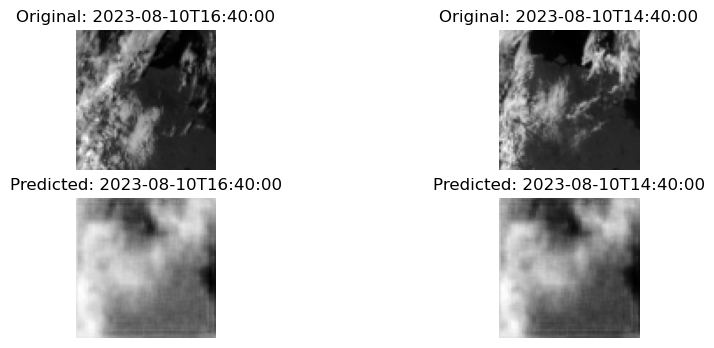

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0213


Test Loss: 0.021271396428346634




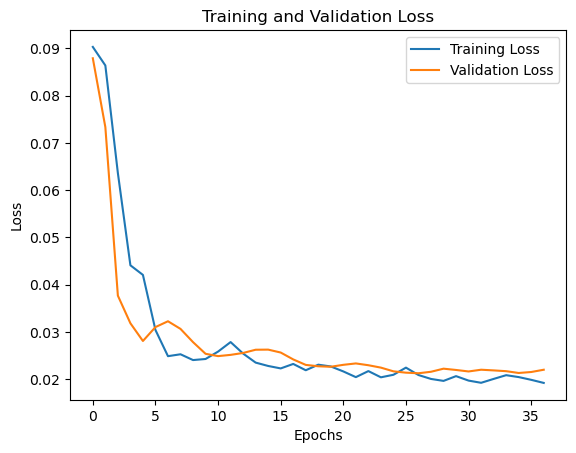

In [3]:
input_layer = Input(shape=(None, 80, 80, 1))

# CNN for feature extraction
cnn_features = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(input_layer)
cnn_features = TimeDistributed(MaxPooling2D((2, 2)))(cnn_features)
cnn_features = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(cnn_features)
cnn_features = TimeDistributed(MaxPooling2D((2, 2)))(cnn_features)
cnn_features = TimeDistributed(Flatten())(cnn_features)

# LSTM for time series analysis
lstm_out = LSTM(50, activation='relu', return_sequences=True)(cnn_features)

# Dropout to prevent overfitting
lstm_out = Dropout(0.5)(lstm_out)

# Reshape for Conv2DTranspose
reshaped = TimeDistributed(Dense(64 * 20 * 20, activation='relu'))(lstm_out)
reshaped = TimeDistributed(Reshape((20, 20, 64)))(reshaped)

# CNN for image reconstruction
decoded = TimeDistributed(Conv2DTranspose(64, (3, 3), activation='relu', padding='same'))(reshaped)
decoded = TimeDistributed(UpSampling2D((2, 2)))(decoded)  # Up to (40, 40)
decoded = TimeDistributed(Conv2DTranspose(32, (3, 3), activation='relu', padding='same'))(decoded)
decoded = TimeDistributed(UpSampling2D((2, 2)))(decoded)  # Up to (80, 80)
decoded = TimeDistributed(Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same'))(decoded)

model = Model(input_layer, decoded)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the model with a larger batch size and more epochs
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Predicting future images
predictions = model.predict(X_test)

# Evaluating the model performance
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test.flatten(), predictions.flatten())
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

def calculate_ssim(y_true, y_pred):
    ssim_scores = []
    for i in range(len(y_true)):
        score = ssim(y_true[i, -1].squeeze(), y_pred[i, -1].squeeze(), data_range=y_pred[i, -1].squeeze().max() - y_pred[i, -1].squeeze().min())
        ssim_scores.append(score)
    return np.mean(ssim_scores)
ssim_score = calculate_ssim(y_test, predictions)
print(f"Average SSIM: {ssim_score}")

# Examples to visualize the predictions with timestamps
n = 2  # Number of examples to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[0][i, :, :, 0], cmap='gray')
    plt.title(f"Original: {test_timestamps[i]}")
    plt.axis("off")

    # Predicted image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(predictions[0][i, :, :, 0], cmap='gray')
    plt.title(f"Predicted: {test_timestamps[i]}")
    plt.axis("off")
plt.show()

# Print the test loss
print("\n\nTest Loss: {}\n\n".format(model.evaluate(X_test, y_test)))

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Using Keras Tuner  (Hyperband)
#### Initaily used to get best set of hyperparameters
#### Were not able to fully utilize as it took very long for processing

In [7]:
# pip install keras-tuner


  Obtaining dependency information for keras-tuner from https://files.pythonhosted.org/packages/db/5d/945296512980b0827e93418514c8be9236baa6f0a1e8ca8be3a2026665b0/keras_tuner-1.4.7-py3-none-any.whl.metadata
  Obtaining dependency information for kt-legacy from https://files.pythonhosted.org/packages/16/53/aca9f36da2516db008017db85a1f3cafaee0efc5fc7a25d94c909651792f/kt_legacy-1.0.5-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --------- ----------------------------- 30.7/129.1 kB 435.7 kB/s eta 0:00:01
   ------------------ -------------------- 61.4/129.1 kB 656.4 kB/s eta 0:00:01
   ---------------------------------------- 129.1/129.1 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Buliding model using keras tuner
def build_model(hp):
    input_layer = Input(shape=(None, 80, 80, 1))

    # CNN for feature extraction
    cnn_features = TimeDistributed(Conv2D(hp.Int('filters_1', min_value=16, max_value=64, step=16), (3, 3), activation='relu', padding='same'))(input_layer)
    cnn_features = TimeDistributed(MaxPooling2D((2, 2)))(cnn_features)
    cnn_features = TimeDistributed(Conv2D(hp.Int('filters_2', min_value=32, max_value=128, step=32), (3, 3), activation='relu', padding='same'))(cnn_features)
    cnn_features = TimeDistributed(MaxPooling2D((2, 2)))(cnn_features)
    cnn_features = TimeDistributed(Flatten())(cnn_features)

    # LSTM for time series analysis
    lstm_out = LSTM(hp.Int('lstm_units', min_value=10, max_value=100, step=10), activation='relu', return_sequences=True)(cnn_features)

    # Size of the Dense layer output
    reshape_filters = hp.Int('reshape_filters', min_value=32, max_value=64, step=32)
    flatten_size = 20 * 20 * reshape_filters

    # Reshape for Conv2DTranspose
    reshaped = TimeDistributed(Dense(flatten_size, activation='relu'))(lstm_out)
    reshaped = TimeDistributed(Reshape((20, 20, hp.Int('reshape_filters', min_value=32, max_value=64, step=32))))(reshaped)

    # CNN for image reconstruction
    decoded = TimeDistributed(Conv2DTranspose(hp.Int('transpose_filters_1', min_value=32, max_value=64, step=32), (3, 3), activation='relu', padding='same'))(reshaped)
    decoded = TimeDistributed(UpSampling2D((2, 2)))(decoded)  # Up to (40, 40)
    decoded = TimeDistributed(Conv2DTranspose(hp.Int('transpose_filters_2', min_value=16, max_value=32, step=16), (3, 3), activation='relu', padding='same'))(decoded)
    decoded = TimeDistributed(UpSampling2D((2, 2)))(decoded)  # Up to (80, 80)
    decoded = TimeDistributed(Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same'))(decoded)

    model = Model(input_layer, decoded)
    # selecting various learning rates
    model.compile(optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])), loss='mse')

    return model


In [9]:
# Setting up keras tuner
# Specifically the 'hyperband'

tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=20,
    factor=3, # reduction factor
    directory='my_dir',
    project_name='cloud_cover_prediction',
    overwrite=True  # only be added to ensure that the previous search is overwritten and NEW search takes place!!
)


In [10]:
# Search for the best Hyperparameters

tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

# Retriving the best option or set of hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The optimal hyperparameters are:
filters_1: {best_hps.get('filters_1')}
filters_2: {best_hps.get('filters_2')}
lstm_units: {best_hps.get('lstm_units')}
reshape_filters: {best_hps.get('reshape_filters')}
transpose_filters_1: {best_hps.get('transpose_filters_1')}
transpose_filters_2: {best_hps.get('transpose_filters_2')}
learning_rate: {best_hps.get('learning_rate')}
""")

Trial 30 Complete [00h 00m 35s]
val_loss: 0.04109235107898712

Best val_loss So Far: 0.021497756242752075
Total elapsed time: 00h 12m 37s

The optimal hyperparameters are:
filters_1: 16
filters_2: 128
lstm_units: 60
reshape_filters: 64
transpose_filters_1: 64
transpose_filters_2: 16
learning_rate: 0.001



In [11]:
# Building the model with the best/optimal hyperparamters
model = tuner.hypermodel.build(best_hps)

# Train the model
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - loss: 0.0904 - val_loss: 0.0901
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step - loss: 0.0896 - val_loss: 0.0872
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step - loss: 0.0861 - val_loss: 0.0710
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step - loss: 0.0551 - val_loss: 0.0433
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step - loss: 0.0682 - val_loss: 0.0408
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step - loss: 0.0656 - val_loss: 0.0329
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step - loss: 0.0512 - val_loss: 0.0280
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - loss: 0.0323 - val_loss: 0.0332
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step - loss: 0.0273 - val_loss: 0.0332
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step - loss: 0.0274 - val_loss: 0.0298
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - loss: 0.0250 - val_loss: 0.0271
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step - loss: 0.0241 - val_los

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Mean Squared Error: 0.024604704349054044
Mean Absolute Error: 0.11573993293990659
Root Mean Squared Error: 0.15685886761370568
Mean Absolute Percentage Error: 1.0717288772683244
R-squared: 0.2513854091875868
Average SSIM: 0.17333626238650401


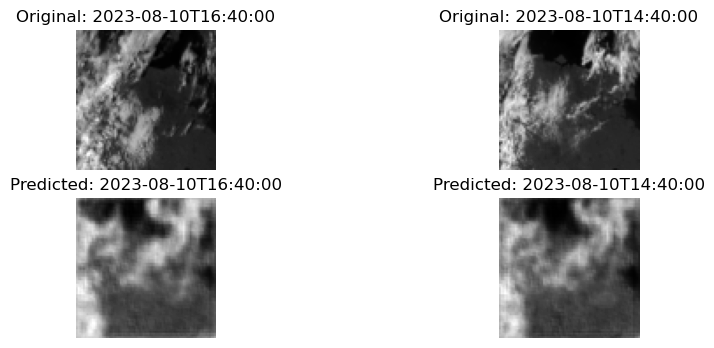

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0246


Test Loss: 0.02460470423102379




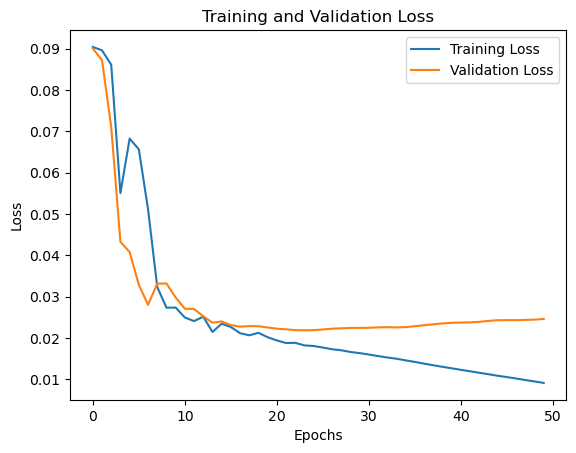

In [12]:
# Evaluating the results
predictions = model.predict(X_test)

mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test.flatten(), predictions.flatten())
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

def calculate_ssim(y_true, y_pred):
    ssim_scores = []
    for i in range(len(y_true)):
        score = ssim(y_true[i, -1].squeeze(), y_pred[i, -1].squeeze(), data_range=y_pred[i, -1].squeeze().max() - y_pred[i, -1].squeeze().min())
        ssim_scores.append(score)
    return np.mean(ssim_scores)
ssim_score = calculate_ssim(y_test, predictions)
print(f"Average SSIM: {ssim_score}")

# Examples to visualize the predictions with timestamps
n = 2  # Number of examples to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[0][i, :, :, 0], cmap='gray')
    plt.title(f"Original: {test_timestamps[i]}")
    plt.axis("off")

    # Predicted image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(predictions[0][i, :, :, 0], cmap='gray')
    plt.title(f"Predicted: {test_timestamps[i]}")
    plt.axis("off")
plt.show()
print("\n\nTest Loss: {}\n\n".format(model.evaluate(X_test, y_test)))

# Val Loss Graph
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
